# 01_连通性判定

演示如何从 CSV 读取圆柱顶点，进行截断、连通性判定（阈值 1.8 nm）。请在运行前确保该仓库的 src/ 在 Python path，或在此 notebook 顶部调整 sys.path。

In [1]:
import os, sys
#repo_root = os.getcwd()
# 获取当前文件的父目录（即 notebooks 目录），再获取其父目录（即项目根目录）
repo_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if repo_root not in sys.path:
    sys.path.append(repo_root)
import numpy as np
import pandas as pd
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity
import matplotlib.pyplot as plt


# 1. 设置支持中文的字体（Windows 常用的是黑体 SimHei 或者微软雅黑 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False  
%matplotlib inline

## 参数（按题目给定）

In [2]:
L = 10000.0  # nm, box size  
r = 30.0    # nm, cylinder radius  
h = 5000.0  # nm, cylinder length  
thresh = 1.8  # nm, surface-to-surface connect threshold

## 读取 CSV（示例）  
假设 CSV 列头为：顶点1_X, 顶点1_Y, 顶点1_Z, 顶点2_X, 顶点2_Y, 顶点2_Z

若你的 CSV 没有表头，请用：pd.read_csv(csv_path, header=None) 并按列索引映射坐标。

In [3]:
#csv_path = 'data/raw/附件_组1.csv'  # 改成你的路径
#df = pd.read_csv(csv_path)
#df.head()
import os
# repo_root 已经在前面定义过了
csv_path = os.path.join(repo_root, 'data/raw/附件_组1.csv')

df = pd.read_csv(csv_path, encoding='gbk',header=1)  # 用第二行（X/Y/Z）作表头
# 手动设置多级列索引
df.columns = pd.MultiIndex.from_tuples([
    ('顶点1', 'X'),
    ('顶点1', 'Y'),
    ('顶点1', 'Z'),
    ('顶点2', 'X'),
    ('顶点2', 'Y'),
    ('顶点2', 'Z')
])
df.head(15)

顶点1                                  顶点2                        
              X           Y           Z            X           Y           Z
0  -5000.000000 -123.595140 -413.210771 -2588.094239  263.800243 -256.916005
1  -5000.000000  260.638630  -45.535533 -2697.575082  420.228820  141.734027
2  -5000.000000  273.505297 -144.677940 -3939.159696  318.937665 -118.265179
3  -4192.318606  261.813019 -199.977020   806.624527  321.530792 -283.651025
4  -2777.977438 -159.004834 -249.729794  2215.332098   97.705863 -280.705585
5  -2262.039518 -250.253829  441.667837  -843.854488 -277.554922  500.000000
6   -843.854488 -277.554922 -500.000000  2732.812454 -346.408362 -352.886108
7    577.038076 -500.000000 -306.636482  5000.000000 -472.318119 -258.403555
8   1066.964138  105.066057 -242.602516  5000.000000  273.505297 -144.677940
9   2330.732535   75.621130 -262.642524  5000.000000  260.638630  -45.535533
10  2656.520725 -500.000000  434.928592  3660.688088 -338.712687  500.000000
11  3660.688088 -338.712687 -500.000000  5000.000000 -123.595140 -413.210771

In [4]:
# 兼容有/无表头: 尝试检测列名
cols = df.columns.tolist()
if len(cols) >= 6:
    # try to find numeric columns
    arr = df.iloc[:, :6].to_numpy(dtype=float)
else:
    raise RuntimeError('CSV must have at least 6 numeric columns for two vertices')
cyls = []
for i, row in enumerate(arr):
    p0 = row[0:3]
    p1 = row[3:6]
    cyls.append(Cylinder(p0, p1, r, id=i))
len(cyls)

12

对每个圆柱做截断并合并片段，然后判断连通性

In [5]:
segments = []
for c in cyls:
    segs = split_cylinder_by_box(c, L)
    segments.extend(segs)
print('原始圆柱:', len(cyls), '截断后片段:', len(segments))
connected, uf = build_connectivity(segments, L, thresh)
print('是否导通:', connected)

原始圆柱: 12 截断后片段: 12
是否导通: False


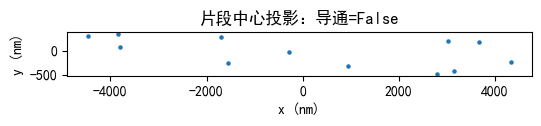

In [6]:
 # 简单可视化：xy 平面投影的圆心与连通簇（仅示意）
centers = np.array([s.center() for s in segments])
xs = centers[:,0]
ys = centers[:,1]
plt.figure(figsize=(6,6))
plt.scatter(xs, ys, s=5)
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.title(f'片段中心投影：导通={connected}')
plt.gca().set_aspect('equal', 'box')
plt.show()

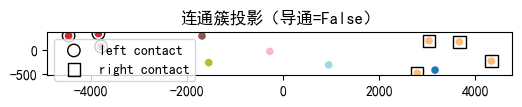

In [7]:
# 为每个片段/原粒子着色显示连通簇（示意）
# 先收集 segments、uf（notebook 中已有 segments, uf, connected）
labels = []
for idx, s in enumerate(segments):
    labels.append(uf.find(idx))
# 把标签压缩成连续整数用于调色
unique = {v:i for i,v in enumerate(sorted(set(labels), key=lambda x: str(x)))}
colors = [unique[l] for l in labels]
centers = np.array([s.center() for s in segments])
plt.figure(figsize=(6,6))
plt.scatter(centers[:,0], centers[:,1], c=colors, s=20, cmap='tab20')
# 标示连接到左右平面的点
left_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','LEFT'))]
right_pts = [i for i,s in enumerate(segments) if uf.find(i) == uf.find(('PLANE','RIGHT'))]
if left_pts:
    plt.scatter(centers[left_pts,0], centers[left_pts,1], edgecolor='k', facecolor='none', s=80, label='left contact')
if right_pts:
    plt.scatter(centers[right_pts,0], centers[right_pts,1], marker='s', edgecolor='k', facecolor='none', s=80, label='right contact')
plt.legend()
plt.title(f'连通簇投影（导通={connected}）')
plt.gca().set_aspect('equal', 'box')
plt.show()

In [8]:
# smoke test: 构造两根很近的短柱，检查它们彼此是否连通（而非电极间连通）
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity, are_indices_connected, are_ids_connected

L = 10000.0; r = 30.0; thresh = 1.8
c1 = Cylinder(np.array([-100.0,0,0]), np.array([-100.0,0,500.0]), r, id=0)
c2 = Cylinder(np.array([-100.0,0,500.0 + (r*2) - 1.0]), np.array([-100.0,0,1000.0]), r, id=1)  # 留 1 nm 表面间隙

segs = []
for c in (c1, c2):
    segs.extend(split_cylinder_by_box(c, L))

connected_planes, uf = build_connectivity(segs, L, thresh)

# 检查两个圆柱的任意一段是否被并到同一集合中
# segments 在 build_connectivity 中按传入顺序索引，所以这里第一根圆柱的片段索引从 0 开始
# 如果 split_cylinder_by_box 为每根只返回一段，则索引 0 和 1 对应两根原始圆柱
assert are_indices_connected(uf, 0, 1), "Smoke test failed: 两个接近的圆柱应被判定为连通"
print('Smoke test passed: 两个圆柱在同一连通簇')

Smoke test passed: 两个圆柱在同一连通簇
